In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
df.shape

(200, 5)

In [7]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [10]:
df=df.drop("CustomerID",axis=1)

In [11]:
num_cols=df.select_dtypes(include=['int64','float64']).columns
print(num_cols)

Index(['Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')


In [13]:
## task-2 Standardization
from sklearn.preprocessing import StandardScaler
num_cols=df[['Age','Annual Income (k$)', 'Spending Score (1-100)']]
scaler=StandardScaler()
scaled_features=scaler.fit_transform(num_cols)
scaled_df=pd.DataFrame(scaled_features,columns=num_cols.columns)
print(scaled_df.head())

        Age  Annual Income (k$)  Spending Score (1-100)
0 -1.424569           -1.738999               -0.434801
1 -1.281035           -1.738999                1.195704
2 -1.352802           -1.700830               -1.715913
3 -1.137502           -1.700830                1.040418
4 -0.563369           -1.662660               -0.395980


In [15]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=2,random_state=42)
kmeans.fit(scaled_df)
labels=kmeans.labels_
scaled_df['cluster']=labels
scaled_df.head()

,Age,Annual Income (k$),Spending Score (1-100),cluster
0,-1.424569,-1.738999,-0.434801,1
1,-1.281035,-1.738999,1.195704,1
2,-1.352802,-1.700830,-1.715913,0
3,-1.137502,-1.700830,1.040418,1
4,-0.563369,-1.662660,-0.395980,1


In [16]:
scaled_df['cluster'].value_counts()

cluster
0    103
1     97
Name: count, dtype: int64

In [17]:
from sklearn.cluster import KMeans

inertia_values = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df.drop('Cluster', axis=1, errors='ignore'))
    
    inertia_values.append(kmeans.inertia_)

# Print results
for k, inertia in zip(k_values, inertia_values):
    print(f"k = {k}, Inertia = {inertia}")

k = 2, Inertia = 389.3861889564371
k = 3, Inertia = 300.2531119773894
k = 4, Inertia = 209.62253632708774
k = 5, Inertia = 170.22068116250614
k = 6, Inertia = 160.5348738057089
k = 7, Inertia = 126.20218606619416
k = 8, Inertia = 117.70826719881573
k = 9, Inertia = 104.98971885049116
k = 10, Inertia = 87.00412244065706


In [30]:
## Task 4
## Change the value of k from 2 to 10 and record inertia for each value.
from sklearn.cluster import KMeans
inertia_val=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(scaled_df.drop('cluster',axis=1,errors='ignore'))
    inertia_val.append(kmeans.inertia_)
for k,inertia in zip(range(2,11),inertia_val):
    print(f" k = {k} ,Inertia = {inertia}")
            

 k = 2 ,Inertia = 389.3861889564371
 k = 3 ,Inertia = 295.45624492135573
 k = 4 ,Inertia = 205.22514747675922
 k = 5 ,Inertia = 169.89149793438588
 k = 6 ,Inertia = 134.3527747740149
 k = 7 ,Inertia = 121.38935022502872
 k = 8 ,Inertia = 113.72723000071333
 k = 9 ,Inertia = 102.1362384432925
 k = 10 ,Inertia = 92.55027231838781


In [32]:
elbow_df=pd.DataFrame({
    "k":list(range(2,11)),
    "Inertia":inertia_val})
elbow_df

,k,Inertia
0,2,389.386189
1,3,295.456245
2,4,205.225147
3,5,169.891498
4,6,134.352775
5,7,121.389350
6,8,113.727230
7,9,102.136238
8,10,92.550272


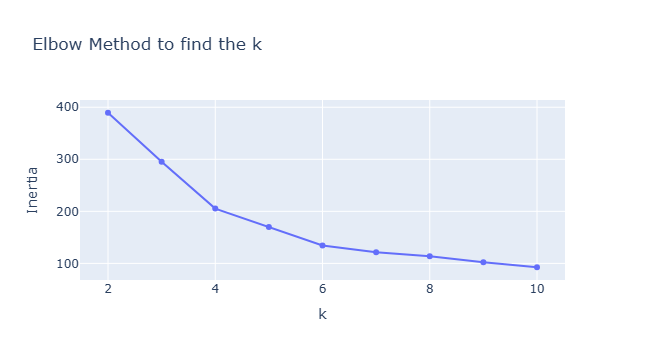

In [33]:
fig=px.line(
    elbow_df,
    x="k",
    y="Inertia",
    markers=True,
    title="Elbow Method to find the k ")
fig.show()

In [37]:
kmeans_final=KMeans(n_clusters=5,random_state=42)
X=scaled_df.drop('cluster',axis=1,errors='ignore')
kmeans_final.fit(X)
final_labels=kmeans_final.labels_
scaled_df["Final_Cluster"]=final_labels
scaled_df.head()

,Age,Annual Income (k$),Spending Score (1-100),cluster,Final_Cluster
0,-1.424569,-1.738999,-0.434801,1,2
1,-1.281035,-1.738999,1.195704,1,2
2,-1.352802,-1.700830,-1.715913,0,3
3,-1.137502,-1.700830,1.040418,1,2
4,-0.563369,-1.662660,-0.395980,1,2


In [38]:
scaled_df.head()

,Age,Annual Income (k$),Spending Score (1-100),cluster,Final_Cluster
0,-1.424569,-1.738999,-0.434801,1,2
1,-1.281035,-1.738999,1.195704,1,2
2,-1.352802,-1.700830,-1.715913,0,3
3,-1.137502,-1.700830,1.040418,1,2
4,-0.563369,-1.662660,-0.395980,1,2


In [39]:
scaled_df['Final_Cluster'].value_counts()

Final_Cluster
0    58
3    45
1    40
4    31
2    26
Name: count, dtype: int64

In [43]:
kmeans_tuned=KMeans(
    n_clusters=5,
    n_init=20,
    max_iter=500,
    random_state=42)
X=scaled_df.drop('Final_Cluster',axis=1,errors='ignore')
kmeans_tuned.fit(X)
scaled_df['Tuned_Cluster']=kmeans_tuned.labels_
(scaled_df.head())

,Age,Annual Income (k$),Spending Score (1-100),cluster,Final_Cluster,Tuned_CLuster,Tuned_Cluster
0,-1.424569,-1.738999,-0.434801,1,2,1,1
1,-1.281035,-1.738999,1.195704,1,2,1,1
2,-1.352802,-1.700830,-1.715913,0,3,2,0
3,-1.137502,-1.700830,1.040418,1,2,1,1
4,-0.563369,-1.662660,-0.395980,1,2,1,1


In [44]:
scaled_df['Tuned_Cluster'].value_counts()

Tuned_Cluster
1    57
3    47
2    40
4    36
0    20
Name: count, dtype: int64

In [46]:
comparison=scaled_df[['Final_Cluster','Tuned_Cluster']]
comparison.head()

,Final_Cluster,Tuned_Cluster
0,2,1
1,2,1
2,3,0
3,2,1
4,2,1


In [48]:
changed=(scaled_df['Final_Cluster']!=scaled_df['Tuned_Cluster']).sum()
print(changed)

154


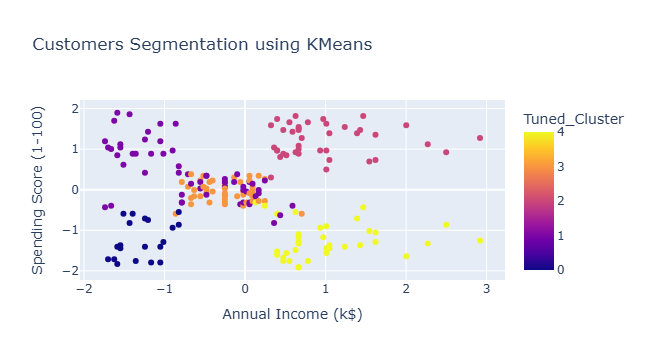

In [52]:
## task-9
fig=px.scatter(
    scaled_df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    color='Tuned_Cluster',
    title="Customers Segmentation using KMeans"
)
fig.show()

In [54]:
df['Cluster']=scaled_df['Tuned_Cluster']

In [55]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,Male,19,15,39,1
1,Male,21,15,81,1
2,Female,20,16,6,0
3,Female,23,16,77,1
4,Female,31,17,40,1


In [56]:
df=pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [58]:
df['Survived'].value_counts() ## ->Target Columns

Survived
0    549
1    342
Name: count, dtype: int64

In [59]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [60]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [63]:
from sklearn.model_selection import train_test_split
X=df[['Pclass','Age','Fare']]
y=df['Survived']
X=X.fillna(X.mean())

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape

(712, 3)

In [64]:
X_test.shape

(179, 3)

In [70]:
## Task-3 ->Classification Model
from sklearn.linear_model import LogisticRegression
model_lo=LogisticRegression()
model_lo.fit(X_train,y_train)

LogisticRegression()

In [74]:
y_pred_lo=model.predict(X_test)
print(y_pred_lo[:10])

[0 0 0 1 0 1 0 0 0 1]


In [73]:
from sklearn.ensemble import RandomForestClassifier
model_ra=RandomForestClassifier()
model_ra.fit(X_train,y_train)

RandomForestClassifier()

In [75]:
y_pred_ra=model.predict(X_test)
print(y_pred_ra[:10])

[0 0 0 1 0 1 0 0 0 1]


In [76]:
from sklearn.metrics import confusion_matrix
cm_lo=confusion_matrix(y_test,y_pred_lo)
cm_ra=confusion_matrix(y_test,y_pred_ra)
print("Logistics Regression COnfusion Matrix")
print(cm_lo)
print("Random Forest Confusion Matrix")
print(cm_ra)


Logistics Regression COnfusion Matrix
[[93 12]
 [35 39]]
Random Forest Confusion Matrix
[[93 12]
 [35 39]]


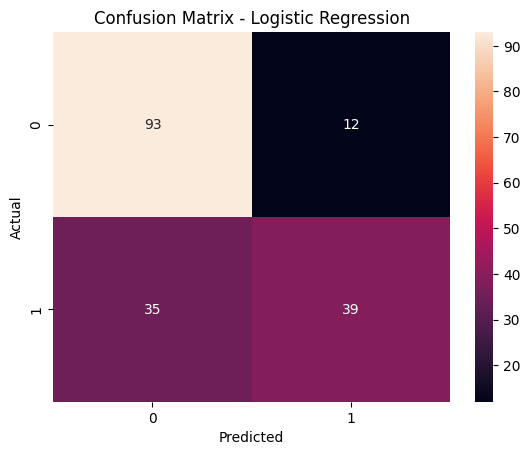

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm_lo, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [79]:
## Task -6 Accuracy->Total correct predicts/totla number of predictions
from sklearn.metrics import accuracy_score
accuracy_lo=accuracy_score(y_test,y_pred_lo)
accuracy_ra=accuracy_score(y_test,y_pred_ra)
print(accuracy_lo)
print(accuracy_ra)

0.7374301675977654
0.7374301675977654


In [80]:
from sklearn.metrics import precision_score
precision_lo=precision_score(y_test,y_pred_lo)
print(precision_lo)

0.7647058823529411


In [81]:
from sklearn.metrics import recall_score
recall=recall_score(y_test,y_pred_lo)
recall

0.527027027027027

In [83]:
from sklearn.metrics import f1_score
f1=f1_score(y_test,y_pred_lo)
f1

0.624

In [84]:
print(accuracy_lo)
print(f1)

0.7374301675977654
0.624
